# Classificação: Primeiros passos

Neste projeto, iremos analisar dados de uma campanha de marketing para aderência de investimentos. O intuito é usar as informações dos dados para prever se os clientes de um banco vão aplicar o dinheiro em um investimento ou não.

Essa previsão será feita utilizando machine learning e este notebook vai conter os passos para se obter um modelo capaz de realizar as previsões, desde a **leitura**, **análise exploratória**, **separação** e **transformação** dos dados, até o **ajuste**, **avaliação** e **comparação** de modelos de classificação.

# Análise exploratória

## Fazendo a leitura dos dados

Podemos realizar a leitura dos dados a partir da biblioteca `pandas`. Por conta disso, vamos realizar a importação da biblioteca com o comando `import pandas as pd`.

Como o arquivo de dados está no formato *csv*, vamos realizar a leitura com a função [`read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import plotly.express as px

In [2]:
df = pd.read_csv(r'C:\Users\Arthur Lindolpho\Documents\data_science_Alura\classificacao\marketing_investimento.csv')

In [3]:
df.head()

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos,aderencia_investimento
0,45,casado (a),superior,nao,242,nao,587,1,sim
1,42,casado (a),medio,nao,1289,nao,250,4,sim
2,23,solteiro (a),superior,nao,363,nao,16,18,nao
3,58,divorciado (a),superior,nao,1382,nao,700,1,sim
4,50,casado (a),medio,nao,3357,nao,239,4,sim


Para criar modelos de classificação, precisamos utilizar dados de qualidade, sem inconsistências e sem dados faltantes. Vamos checar se existem dados nulos e o tipo dos dados de cada coluna na base de dados a partir do método [`info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html).

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268 entries, 0 to 1267
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   idade                   1268 non-null   int64 
 1   estado_civil            1268 non-null   object
 2   escolaridade            1268 non-null   object
 3   inadimplencia           1268 non-null   object
 4   saldo                   1268 non-null   int64 
 5   fez_emprestimo          1268 non-null   object
 6   tempo_ult_contato       1268 non-null   int64 
 7   numero_contatos         1268 non-null   int64 
 8   aderencia_investimento  1268 non-null   object
dtypes: int64(4), object(5)
memory usage: 89.3+ KB


In [5]:
df.describe()

,idade,saldo,tempo_ult_contato,numero_contatos
count,1268.000000,1268.000000,1268.000000,1268.000000
mean,41.376972,1443.426656,367.574921,2.715300
std,11.383805,2690.406767,347.969723,2.885642
min,19.000000,-1206.000000,5.000000,1.000000
25%,33.000000,91.250000,134.000000,1.000000
50%,39.000000,491.500000,251.000000,2.000000
75%,49.000000,1623.500000,488.250000,3.000000
max,87.000000,27069.000000,3025.000000,32.000000


### Variáveis Categóricas

In [6]:
px.histogram(df, x = 'aderencia_investimento', text_auto=True , title = 'Aderência ao investimento')

In [7]:
px.histogram(df, x = 'estado_civil', text_auto=True ,color = 'aderencia_investimento', barmode='group')

In [8]:
px.histogram(df, x = 'escolaridade', text_auto=True ,color = 'aderencia_investimento', barmode='group')

In [9]:
px.histogram(df, x = 'inadimplencia', text_auto=True ,color = 'aderencia_investimento', barmode='group')

In [10]:
px.histogram(df, x = 'fez_emprestimo', text_auto=True ,color = 'aderencia_investimento', barmode='group')

### Variáveis numéricas

In [11]:
px.box(df, x = 'idade', color = 'aderencia_investimento')

In [12]:
px.box(df, x = 'saldo', color = 'aderencia_investimento')

In [13]:
px.box(df, x = 'tempo_ult_contato', color = 'aderencia_investimento')

In [14]:
px.box(df, x = 'numero_contatos', color = 'aderencia_investimento')

<Axes: >

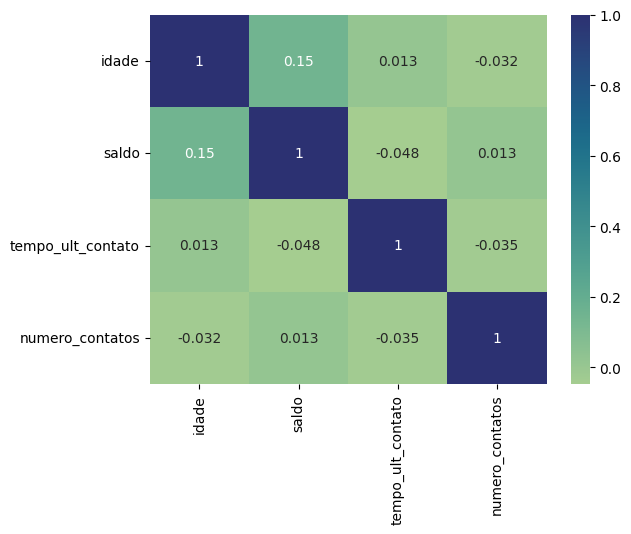

In [15]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot = True, cmap = 'crest')

### Separando as Variáveis

In [16]:
# Variável alvo
y = df['aderencia_investimento']

# Variáveis explicativas
X = df.drop(columns='aderencia_investimento')

### Transformando as variáveis categóricas em variáveis numéricas

In [17]:
df.head()

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos,aderencia_investimento
0,45,casado (a),superior,nao,242,nao,587,1,sim
1,42,casado (a),medio,nao,1289,nao,250,4,sim
2,23,solteiro (a),superior,nao,363,nao,16,18,nao
3,58,divorciado (a),superior,nao,1382,nao,700,1,sim
4,50,casado (a),medio,nao,3357,nao,239,4,sim


In [18]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [19]:
colunas = X.columns
colunas

Index(['idade', 'estado_civil', 'escolaridade', 'inadimplencia', 'saldo',
       'fez_emprestimo', 'tempo_ult_contato', 'numero_contatos'],
      dtype='object')

In [20]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['estado_civil', 'escolaridade', 'inadimplencia', 'fez_emprestimo']
),
    remainder= 'passthrough',
    sparse_threshold=0)

In [21]:
X = one_hot.fit_transform(X)

In [22]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__estado_civil_casado (a)',
       'onehotencoder__estado_civil_divorciado (a)',
       'onehotencoder__estado_civil_solteiro (a)',
       'onehotencoder__escolaridade_fundamental',
       'onehotencoder__escolaridade_medio',
       'onehotencoder__escolaridade_superior',
       'onehotencoder__inadimplencia_sim',
       'onehotencoder__fez_emprestimo_sim', 'remainder__idade',
       'remainder__saldo', 'remainder__tempo_ult_contato',
       'remainder__numero_contatos'], dtype=object)

In [23]:
pd.DataFrame(X, columns= one_hot.get_feature_names_out(colunas))

,onehotencoder__estado_civil_casado (a),onehotencoder__estado_civil_divorciado (a),onehotencoder__estado_civil_solteiro (a),onehotencoder__escolaridade_fundamental,onehotencoder__escolaridade_medio,onehotencoder__escolaridade_superior,onehotencoder__inadimplencia_sim,onehotencoder__fez_emprestimo_sim,remainder__idade,remainder__saldo,remainder__tempo_ult_contato,remainder__numero_contatos
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,45.0,242.0,587.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,42.0,1289.0,250.0,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,23.0,363.0,16.0,18.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,58.0,1382.0,700.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,3357.0,239.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1263,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,52.0,83.0,1223.0,6.0
1264,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,35.0,5958.0,215.0,1.0
1265,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,30.0,-477.0,1532.0,2.0
1266,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,42.0,2187.0,525.0,3.0


Transformando a variável alvo

In [24]:
from sklearn.preprocessing import LabelEncoder

In [25]:
label_encoder = LabelEncoder()

In [26]:
y = label_encoder.fit_transform(y)

Fazendo a separação da base de dadoss

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify= y, test_size= 0.2, random_state=5)

### Dummy Classifier

In [29]:
from sklearn.dummy import DummyClassifier


In [33]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)

,strategy,'prior'
,random_state,None
,constant,None


In [36]:
dummy.score(X_test, y_test)

0.6023622047244095

### Decision Tree

In [60]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

In [43]:
arvore = DecisionTreeClassifier(random_state= 5)
arvore.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [50]:
arvore.predict(X_test)

array([0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1])

In [49]:
arvore.score(X_test, y_test)

0.6811023622047244

In [51]:
from sklearn.tree import plot_tree


In [53]:
colunas = [
    'casado (a)',
       'divorciado (a)',
       'solteiro (a)',
       'fundamental',
       'medio',
       'superior',
       'inadimplencia',
       'fez_emprestimo', 'idade',
       'saldo', 'tempo_ult_contato',
       'numero_contatos'
]

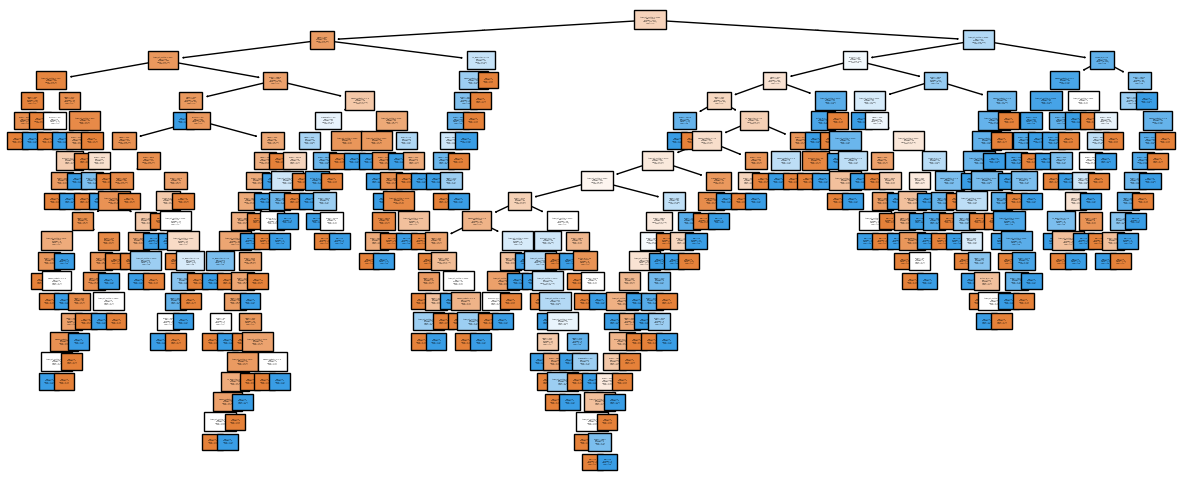

In [54]:
plt.figure(figsize= (15,6))
plot_tree(arvore, filled=True, class_names=['nao', 'sim'], fontsize=1, feature_names=colunas)
plt.show()

In [65]:
arvore.score(X_train, y_train)

1.0

OVERFITTING

In [130]:
arvore = DecisionTreeClassifier(random_state= 5, max_depth=4)
arvore.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [131]:
arvore.score(X_train, y_train)

0.772189349112426

In [132]:
arvore.score(X_test, y_test)

0.7125984251968503

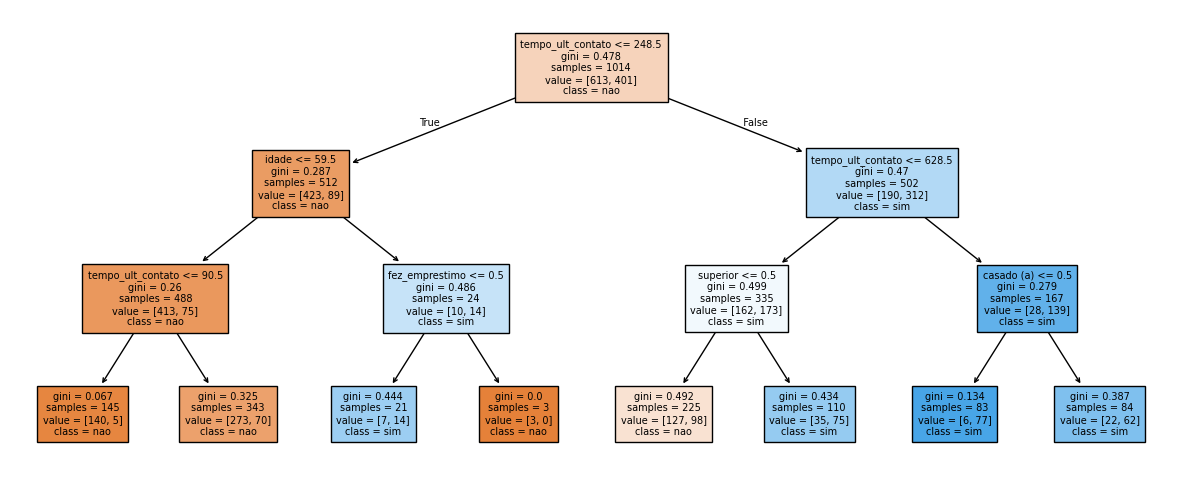

In [71]:
plt.figure(figsize= (15,6))
plot_tree(arvore, filled=True, class_names=['nao', 'sim'], fontsize=7, feature_names=colunas)
plt.show()

### Normalização

In [ ]:
from sklearn.preprocessing import MinMaxScaler


In [85]:
normalizacao = MinMaxScaler()
X_train_normalizado = normalizacao.fit_transform(X_train)

In [86]:
pd.DataFrame(X_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.441176,0.086649,0.126266,0.064516
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.529412,0.050939,0.061505,0.064516
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.264706,0.129495,0.031114,0.064516
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.294118,0.079088,0.005427,0.064516
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.308824,0.062050,0.655210,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
1009,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.205882,0.059778,0.170043,0.032258
1010,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.088235,0.054986,0.134588,0.000000
1011,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.323529,0.042952,0.024964,0.129032
1012,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.176471,0.042810,0.023878,0.000000


### KNN

In [87]:
from sklearn.neighbors import KNeighborsClassifier

In [88]:
knn = KNeighborsClassifier()
knn.fit(X_train_normalizado, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [90]:
X_test_normalizado = normalizacao.fit_transform(X_test)

In [91]:
knn.score(X_test_normalizado, y_test)

0.6811023622047244

### RandomForest

In [96]:
from sklearn.ensemble import RandomForestClassifier

In [122]:
random_forest = RandomForestClassifier(max_depth=4, max_leaf_nodes=10, max_features=5, n_estimators=20)
random_forest.fit(X_train_normalizado, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,5
,max_leaf_nodes,10
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [123]:
random_forest.score(X_test_normalizado, y_test)

0.7559055118110236

### Escolhendo e salvando o melhor modelo

In [124]:
print(f'Acurácia Dummy: {dummy.score(X_test, y_test)}')
print(f'Acurácia Decision Tree: {arvore.score(X_test, y_test)}')
print(f'Acurácia KNN: {knn.score(X_test_normalizado, y_test)}')
print(f'Acurácia Random Forest: {random_forest.score(X_test_normalizado, y_test)}')

Acurácia Dummy: 0.6023622047244095
Acurácia Decision Tree: 0.7125984251968503
Acurácia KNN: 0.6811023622047244
Acurácia Random Forest: 0.7559055118110236


In [135]:
import pickle

In [136]:
with open('Modelo_onehotenc.pkl', 'wb') as arquivo:
    pickle.dump(one_hot, arquivo)

In [137]:
with open('Modelo_random_forest.pkl', 'wb') as arquivo:
    pickle.dump(random_forest, arquivo)

In [138]:
df

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos,aderencia_investimento
0,45,casado (a),superior,nao,242,nao,587,1,sim
1,42,casado (a),medio,nao,1289,nao,250,4,sim
2,23,solteiro (a),superior,nao,363,nao,16,18,nao
3,58,divorciado (a),superior,nao,1382,nao,700,1,sim
4,50,casado (a),medio,nao,3357,nao,239,4,sim
...,...,...,...,...,...,...,...,...,...
1263,52,solteiro (a),superior,nao,83,nao,1223,6,sim
1264,35,solteiro (a),superior,nao,5958,nao,215,1,sim
1265,30,solteiro (a),superior,nao,-477,sim,1532,2,sim
1266,42,casado (a),superior,nao,2187,nao,525,3,sim


In [139]:
novo_dado = {
    'idade': [45],
    'estado_civil': ['solteiro (a)'],
    'escolaridade': ['superior'],
    'inadimplencia': ['nao'], 
    'saldo': [23040],
    'fez_emprestimo': ['nao'],
    'tempo_ult_contato': [800],
    'numero_contatos': [4]
}

In [140]:
novo_dado = pd.DataFrame(novo_dado)
novo_dado

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos
0,45,solteiro (a),superior,nao,23040,nao,800,4


In [141]:
modelo_one_hot = pd.read_pickle(r'C:\Users\Arthur Lindolpho\Documents\data_science_Alura\classificacao\Modelo_onehotenc.pkl')
modelo_random = pd.read_pickle(r'C:\Users\Arthur Lindolpho\Documents\data_science_Alura\classificacao\Modelo_random_forest.pkl')

In [143]:
novo_dado = modelo_one_hot.transform(novo_dado)
modelo_random.predict(novo_dado)

array([1])